In [ ]:
# -------------------------------
# Step 0: Import required libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from prince import FAMD
from sklearn.decomposition import PCA

# Set plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [ ]:

# -------------------------------
# Step 1: Load data
# -------------------------------
Medicalpremium = pd.read_csv("Medicalpremium.csv")
print(f"Dataset shape: {Medicalpremium.shape}")
print(f"\nColumns: {list(Medicalpremium.columns)}")


Dataset shape: (986, 11)

Columns: ['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice']


In [ ]:
# -------------------------------
# Step 2: Explore data (revised)
# -------------------------------
print("\nSummary statistics:")
print(Medicalpremium.describe(include='all'))

print("\nData types:")
print(Medicalpremium.dtypes)

print("\nFirst 5 rows:")
print(Medicalpremium.head())

# Now treat NumberOfMajorSurgeries as numeric
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", 
                    "KnownAllergies", "HistoryOfCancerInFamily","BloodPressureProblems"]  # Removed NumberOfMajorSurgeries

numeric_cols = Medicalpremium.select_dtypes(include=[np.number]).columns.tolist()  # includes NumberOfMajorSurgeries

# Frequency tables for categorical variables
for col in categorical_cols:
    if col in Medicalpremium.columns:
        print(f"\nValue counts for {col}:")
        print(Medicalpremium[col].value_counts())

# -------------------------------
# Step 3: Check missing values and zeros
# -------------------------------
print("\nMissing values per column:")
print(Medicalpremium.isna().sum())

print("\nZeros per numeric column:")
print((Medicalpremium[numeric_cols] == 0).sum())



Summary statistics:
              Age    Diabetes  BloodPressureProblems  AnyTransplants  \
count  986.000000  986.000000             986.000000      986.000000   
mean    41.745436    0.419878               0.468560        0.055781   
std     13.963371    0.493789               0.499264        0.229615   
min     18.000000    0.000000               0.000000        0.000000   
25%     30.000000    0.000000               0.000000        0.000000   
50%     42.000000    0.000000               0.000000        0.000000   
75%     53.000000    1.000000               1.000000        0.000000   
max     66.000000    1.000000               1.000000        1.000000   

       AnyChronicDiseases      Height      Weight  KnownAllergies  \
count          986.000000  986.000000  986.000000      986.000000   
mean             0.180527  168.182556   76.950304        0.215010   
std              0.384821   10.098155   14.265096        0.411038   
min              0.000000  145.000000   51.000000     

In [ ]:

# -------------------------------
# Step 4: Feature engineering (BMI)
# -------------------------------
Medicalpremium['BMI'] = Medicalpremium['Weight'] / ((Medicalpremium['Height'] / 100) ** 2)
print("\nBMI summary:")
print(Medicalpremium['BMI'].describe())



BMI summary:
count    986.000000
mean      27.460709
std        5.878671
min       15.156281
25%       23.393392
50%       27.156602
75%       30.759870
max       50.000000
Name: BMI, dtype: float64


In [ ]:

# -------------------------------
# Step 5: Train-test split
# -------------------------------
train_data, test_data = train_test_split(Medicalpremium, test_size=0.2, random_state=123)
print(f"\nTraining set size: {train_data.shape}")
print(f"Testing set size: {test_data.shape}")



Training set size: (788, 12)
Testing set size: (198, 12)



PIE CHARTS FOR CATEGORICAL VARIABLES (TRAINING SET)


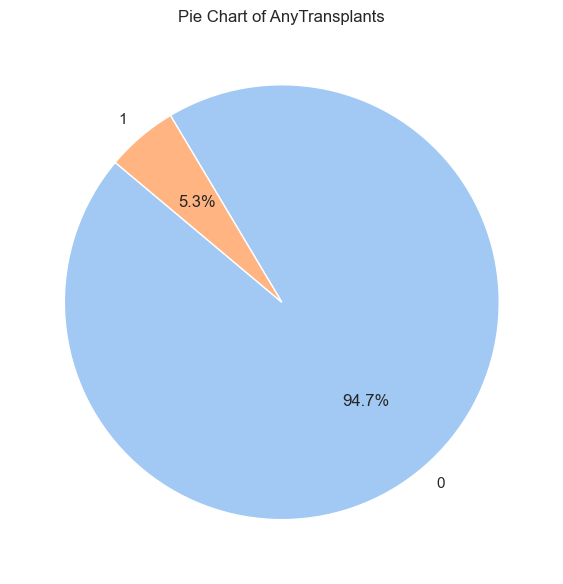

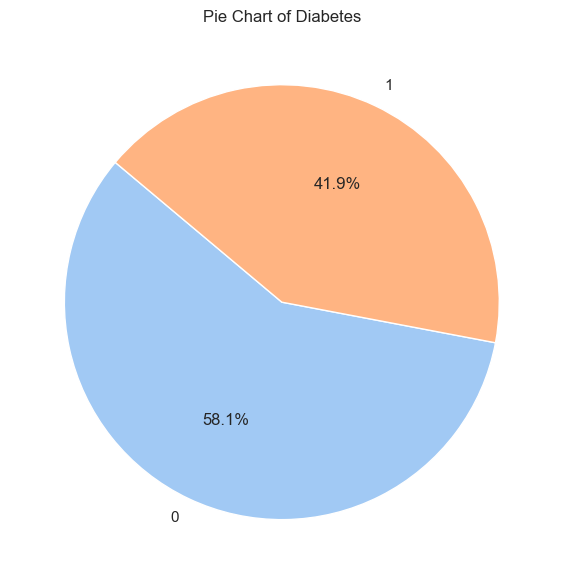

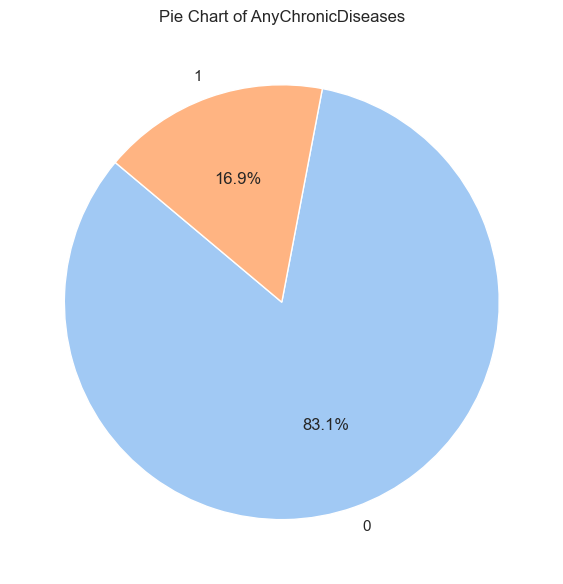

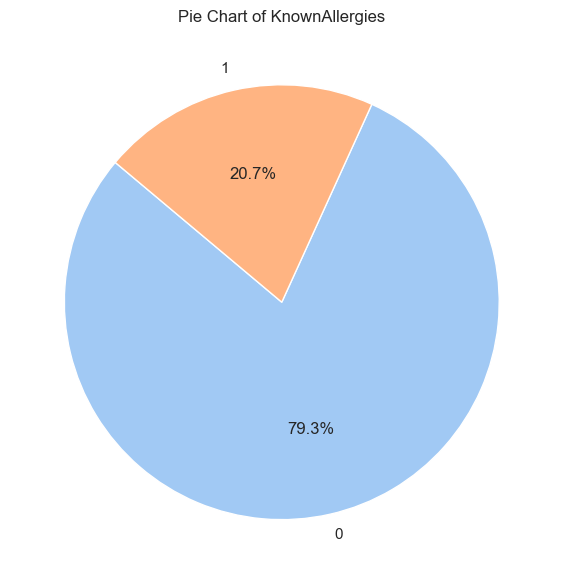

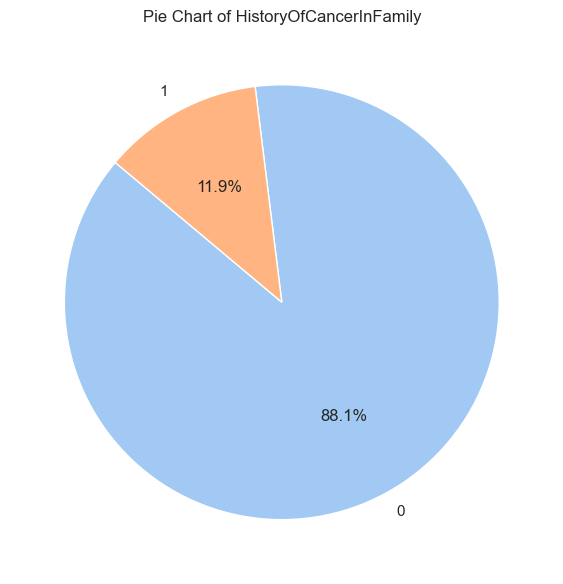

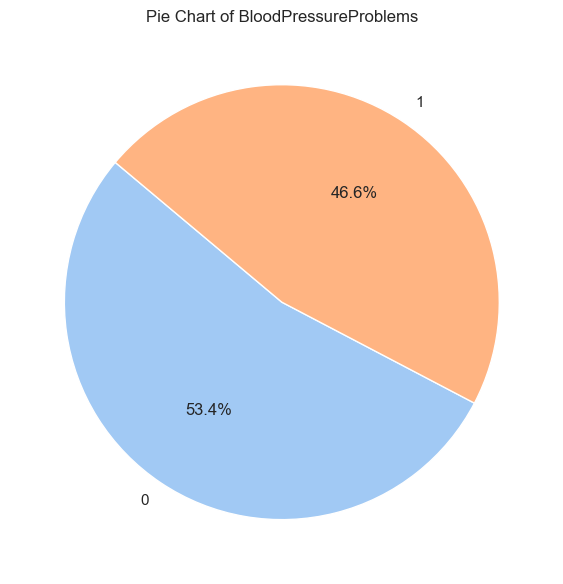

In [ ]:
# -------------------------------
# Step 7: Pie Charts for Categorical Variables (Training Set)
# -------------------------------
print("\n" + "="*60)
print("PIE CHARTS FOR CATEGORICAL VARIABLES (TRAINING SET)")
print("="*60)

for col in categorical_cols:
    if col in train_data.columns:
        counts = train_data[col].value_counts()
        plt.figure(figsize=(6,6))
        plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
                colors=sns.color_palette('pastel'))
        plt.title(f"Pie Chart of {col}")
        plt.tight_layout()
        plt.show()



HISTOGRAMS FOR NUMERIC PREDICTORS


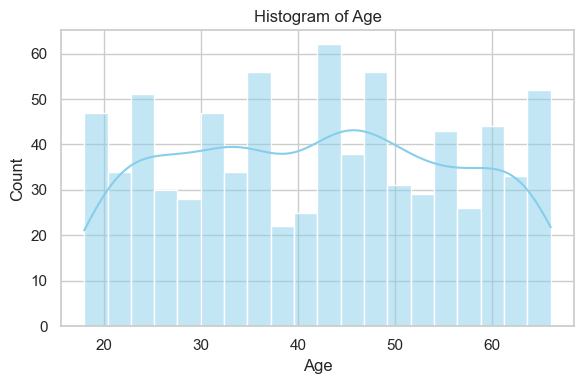

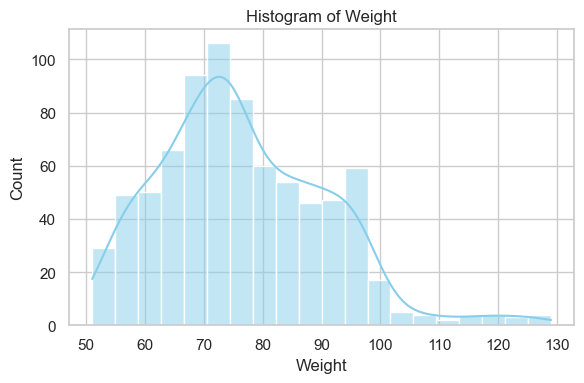

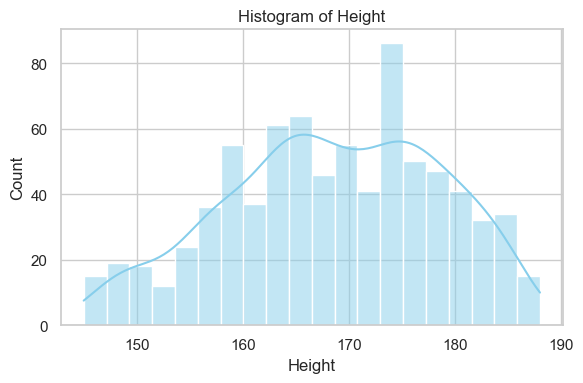

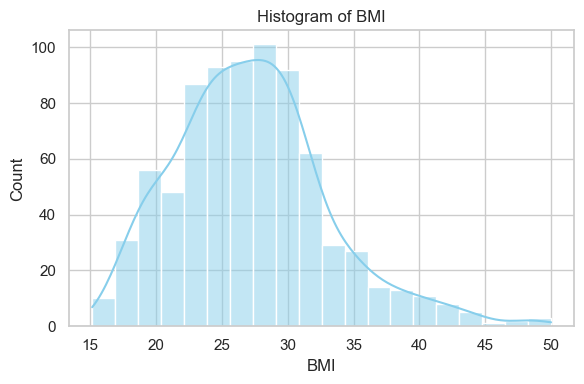

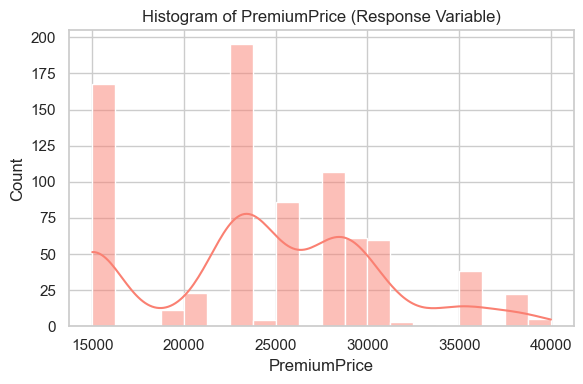

In [ ]:
# -------------------------------
# Step 6: Histograms for Numeric Predictors
# -------------------------------
print("\n" + "="*60)
print("HISTOGRAMS FOR NUMERIC PREDICTORS")
print("="*60)

# Explicit numeric predictors (exclude response 'PremiumPrice')
numeric_predictors = ['Age', 'Weight', 'Height', 'BMI']  # adjust if needed

for col in numeric_predictors:
    if col in train_data.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(train_data[col], bins=20, kde=True, color='skyblue')
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

# Optional: plot the response variable separately
if 'PremiumPrice' in train_data.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(train_data['PremiumPrice'], bins=20, kde=True, color='salmon')
    plt.title("Histogram of PremiumPrice (Response Variable)")
    plt.xlabel("PremiumPrice")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



BOXPLOTS FOR NUMERIC VARIABLES (TRAINING SET)


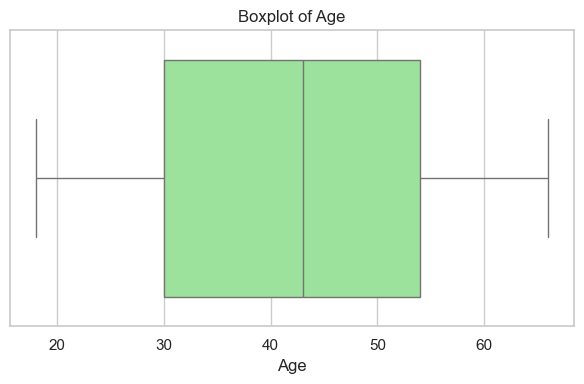

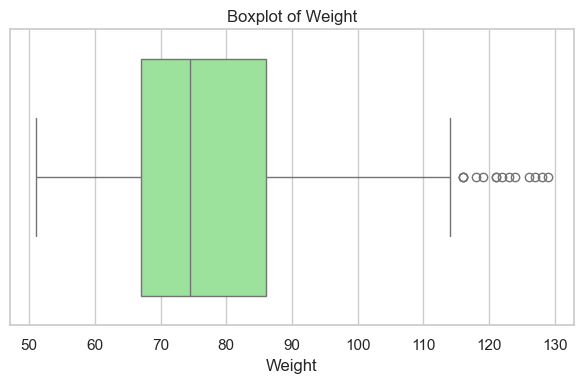

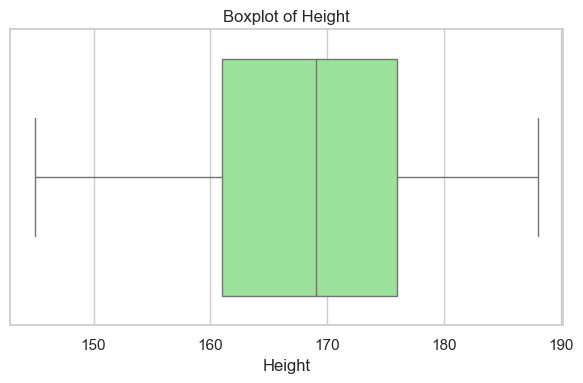

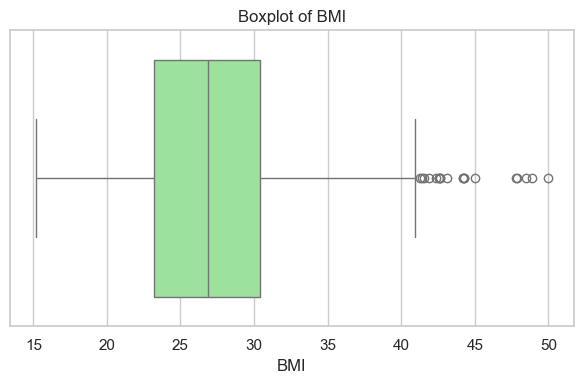

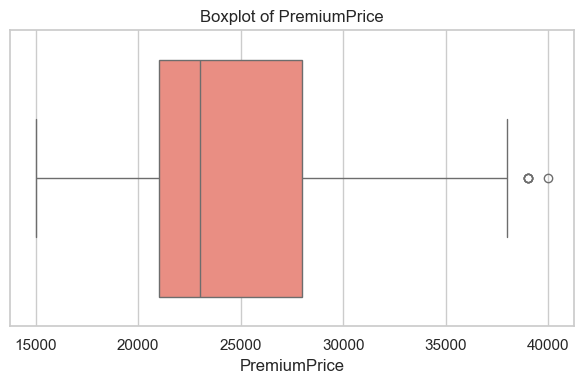

In [ ]:
# -------------------------------
# Step 8: Boxplots for Numeric Variables (Training Set)
# -------------------------------
print("\n" + "="*60)
print("BOXPLOTS FOR NUMERIC VARIABLES (TRAINING SET)")
print("="*60)

# Numeric predictors + response variable
numeric_cols_for_boxplot = ['Age', 'Weight', 'Height', 'BMI', 'PremiumPrice']

for col in numeric_cols_for_boxplot:
    if col in train_data.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=train_data[col], color='lightgreen' if col != 'PremiumPrice' else 'salmon')
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()



OUTLIER DETECTION FOR TRAINING SET


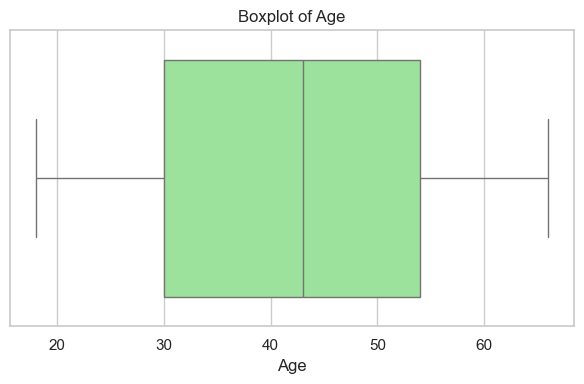

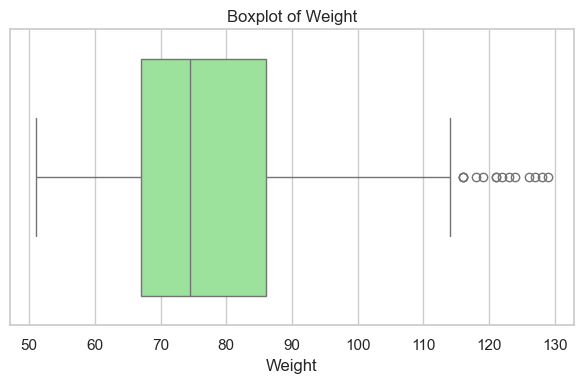

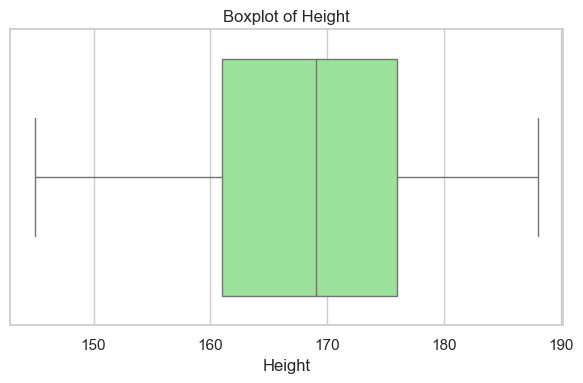

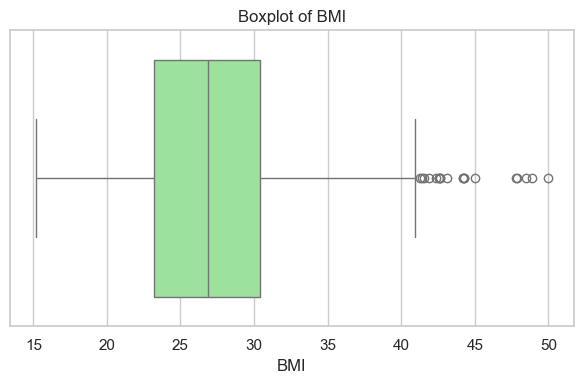

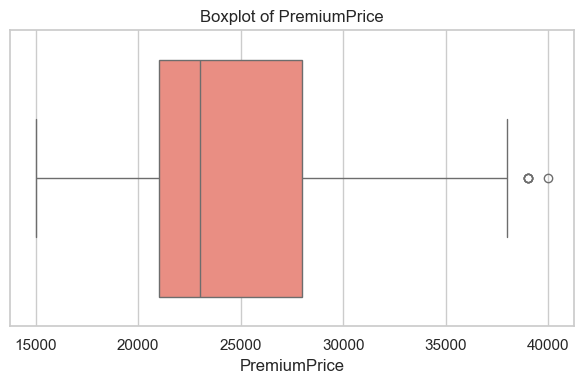


Number of outliers detected by Isolation Forest: 40
Number of inliers: 748


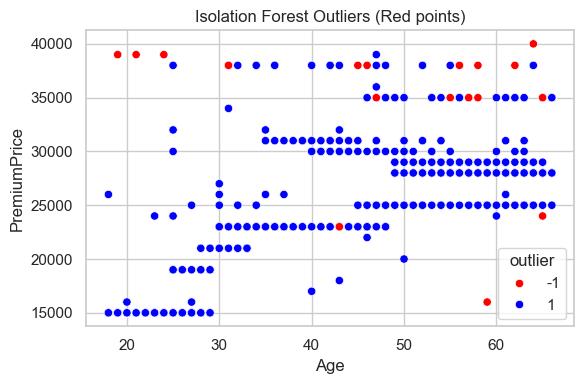

In [ ]:
# -------------------------------
# Step 8: Outlier Detection (Boxplots + Isolation Forest)
# -------------------------------
from sklearn.ensemble import IsolationForest

print("\n" + "="*60)
print("OUTLIER DETECTION FOR TRAINING SET")
print("="*60)

# Numeric predictors + response variable
numeric_cols_for_outliers = ['Age', 'Weight', 'Height', 'BMI', 'PremiumPrice']

# 1️⃣ Boxplots
for col in numeric_cols_for_outliers:
    if col in train_data.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=train_data[col], color='lightgreen' if col != 'PremiumPrice' else 'salmon')
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

# 2️⃣ Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=123)  # 5% expected outliers
iso_forest.fit(train_data[numeric_cols_for_outliers])

# Predict outliers (-1 = outlier, 1 = inlier)
train_data['outlier'] = iso_forest.predict(train_data[numeric_cols_for_outliers])

# Separate outliers and inliers
outliers = train_data[train_data['outlier'] == -1]
inliers = train_data[train_data['outlier'] == 1]

print(f"\nNumber of outliers detected by Isolation Forest: {len(outliers)}")
print(f"Number of inliers: {len(inliers)}")

# 3️⃣ Optional: Scatter plot to visualize (using Age vs PremiumPrice)
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=train_data,
    x='Age', y='PremiumPrice',
    hue='outlier',
    palette={1:'blue', -1:'red'}
)
plt.title("Isolation Forest Outliers (Red points)")
plt.xlabel("Age")
plt.ylabel("PremiumPrice")
plt.tight_layout()
plt.show()


Numeric vs Numeric (correlation + scatter plots)


Correlation matrix:
                   Age    Weight    Height       BMI  PremiumPrice
Age           1.000000 -0.006556  0.025975 -0.021925      0.718306
Weight       -0.006556  1.000000  0.062598  0.821072      0.134883
Height        0.025975  0.062598  1.000000 -0.507840      0.026264
BMI          -0.021925  0.821072 -0.507840  1.000000      0.099873
PremiumPrice  0.718306  0.134883  0.026264  0.099873      1.000000


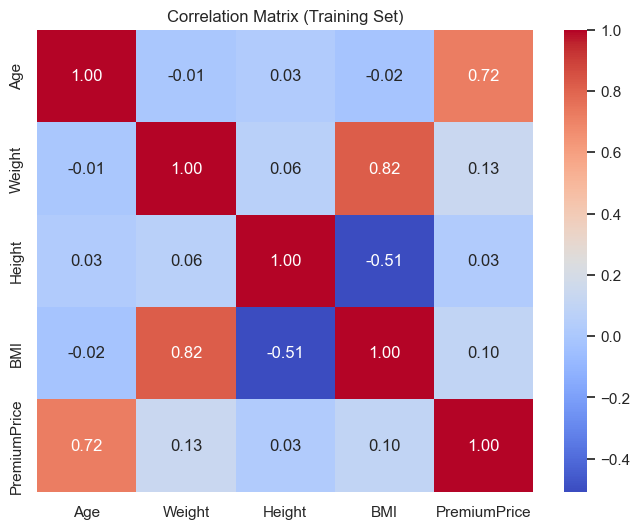

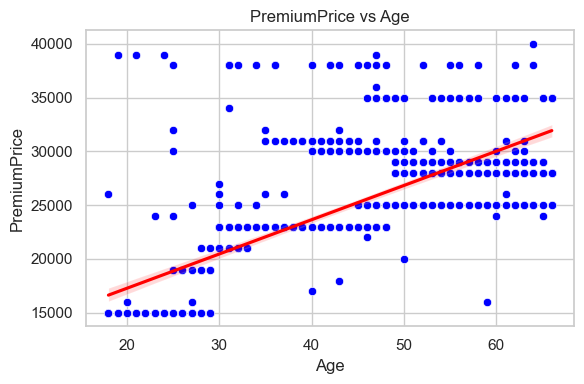

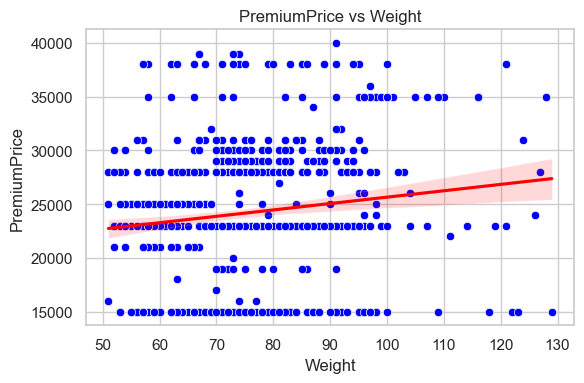

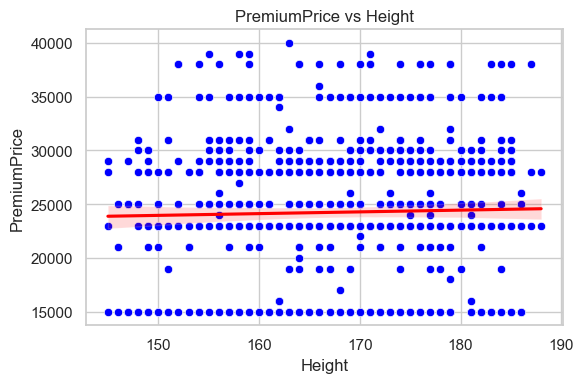

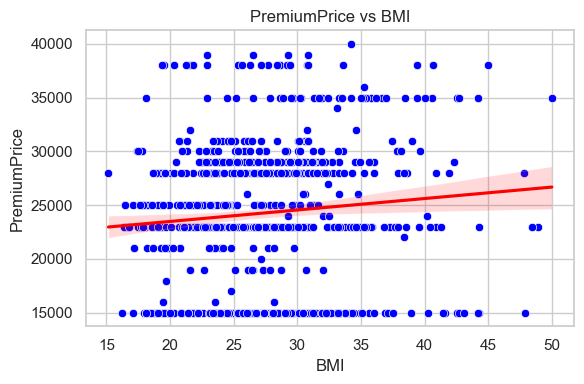

In [ ]:
# Numeric predictors + response
numeric_cols = ['Age', 'Weight', 'Height', 'BMI', 'PremiumPrice']

# Correlation matrix
corr_matrix = train_data[numeric_cols].corr()
print("\nCorrelation matrix:")
print(corr_matrix)

# Heatmap of correlations
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Training Set)")
plt.show()

# Scatter plots with regression line
for col in numeric_cols:
    if col != 'PremiumPrice':  # predictors vs response
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=train_data[col], y=train_data['PremiumPrice'], color='blue')
        sns.regplot(x=train_data[col], y=train_data['PremiumPrice'], scatter=False, color='red')
        plt.title(f"PremiumPrice vs {col}")
        plt.xlabel(col)
        plt.ylabel("PremiumPrice")
        plt.tight_layout()
        plt.show()


Numeric vs Categorical

C:\Users\sahan\AppData\Local\Temp\ipykernel_10552\1933941142.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=train_data[cat_col], y=train_data['PremiumPrice'], palette='pastel')


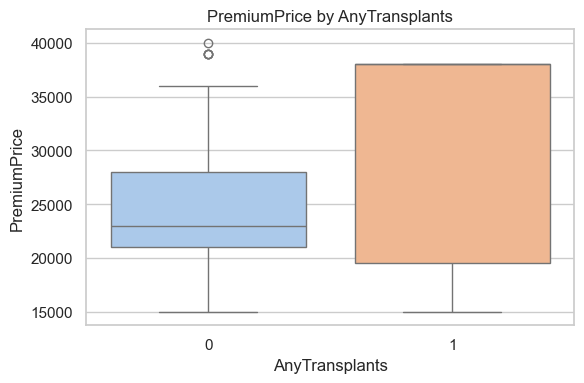

C:\Users\sahan\AppData\Local\Temp\ipykernel_10552\1933941142.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=train_data[cat_col], y=train_data['PremiumPrice'], palette='pastel')


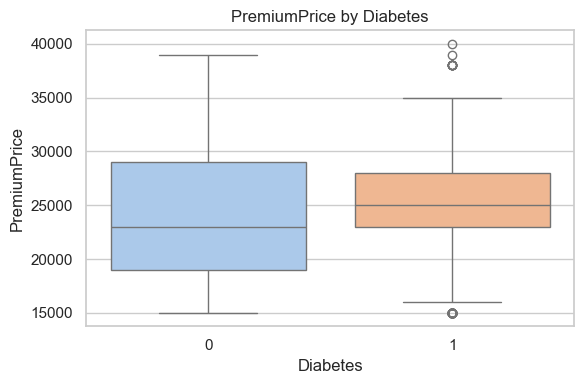

C:\Users\sahan\AppData\Local\Temp\ipykernel_10552\1933941142.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=train_data[cat_col], y=train_data['PremiumPrice'], palette='pastel')


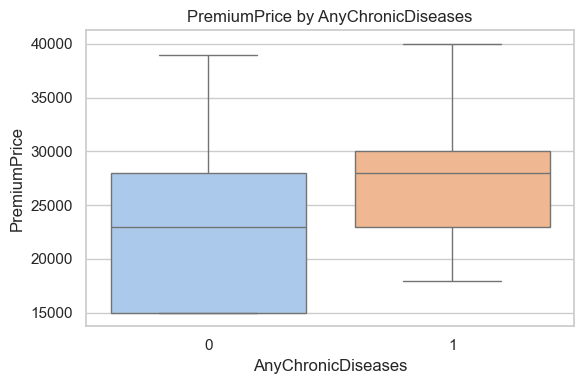

C:\Users\sahan\AppData\Local\Temp\ipykernel_10552\1933941142.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=train_data[cat_col], y=train_data['PremiumPrice'], palette='pastel')


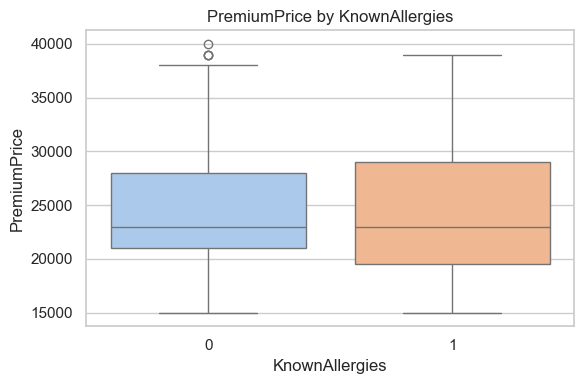

C:\Users\sahan\AppData\Local\Temp\ipykernel_10552\1933941142.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=train_data[cat_col], y=train_data['PremiumPrice'], palette='pastel')


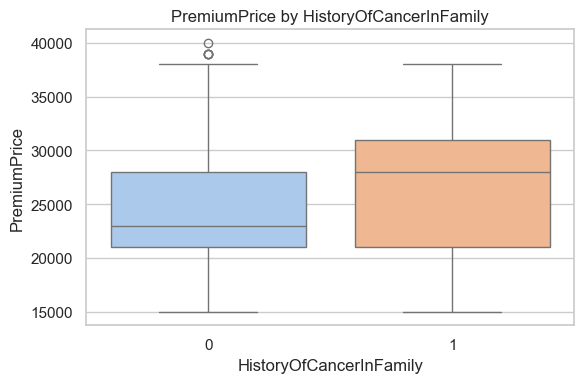

C:\Users\sahan\AppData\Local\Temp\ipykernel_10552\1933941142.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=train_data[cat_col], y=train_data['PremiumPrice'], palette='pastel')


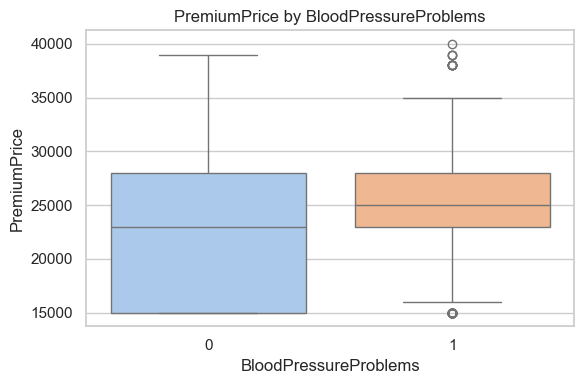

In [ ]:
categorical_cols = ["AnyTransplants", "Diabetes", "AnyChronicDiseases", 
                    "KnownAllergies", "HistoryOfCancerInFamily","BloodPressureProblems"]

for cat_col in categorical_cols:
    if cat_col in train_data.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=train_data[cat_col], y=train_data['PremiumPrice'], palette='pastel')
        plt.title(f"PremiumPrice by {cat_col}")
        plt.xlabel(cat_col)
        plt.ylabel("PremiumPrice")
        plt.tight_layout()
        plt.show()


Categorical vs Categorical (optional)


Crosstab: AnyTransplants vs Diabetes
Diabetes          0    1
AnyTransplants          
0               432  314
1                26   16


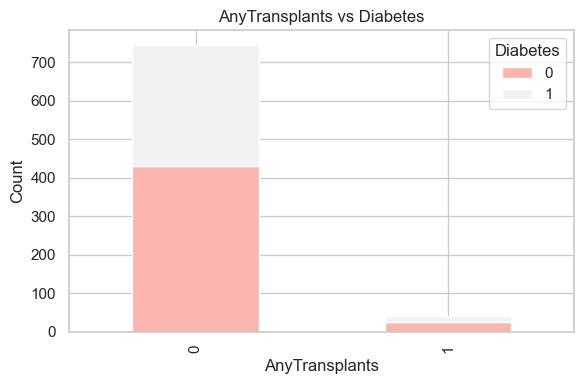


Crosstab: AnyTransplants vs AnyChronicDiseases
AnyChronicDiseases    0    1
AnyTransplants              
0                   621  125
1                    34    8


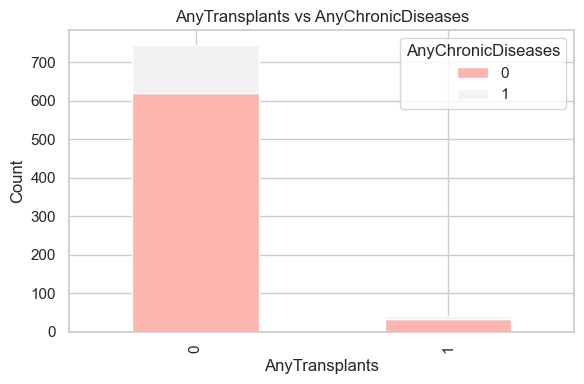


Crosstab: AnyTransplants vs KnownAllergies
KnownAllergies    0    1
AnyTransplants          
0               593  153
1                32   10


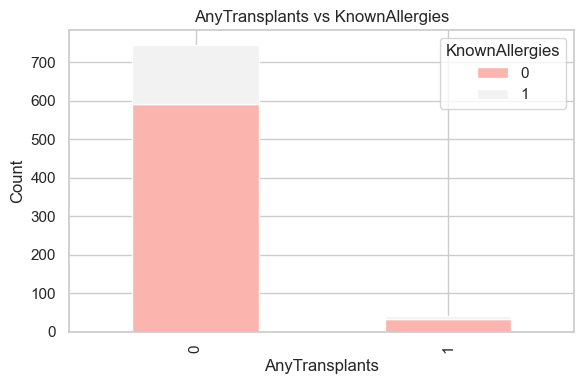


Crosstab: AnyTransplants vs HistoryOfCancerInFamily
HistoryOfCancerInFamily    0   1
AnyTransplants                  
0                        657  89
1                         37   5


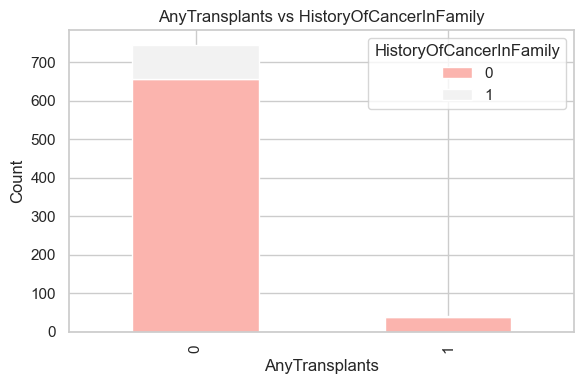


Crosstab: Diabetes vs AnyChronicDiseases
AnyChronicDiseases    0   1
Diabetes                   
0                   366  92
1                   289  41


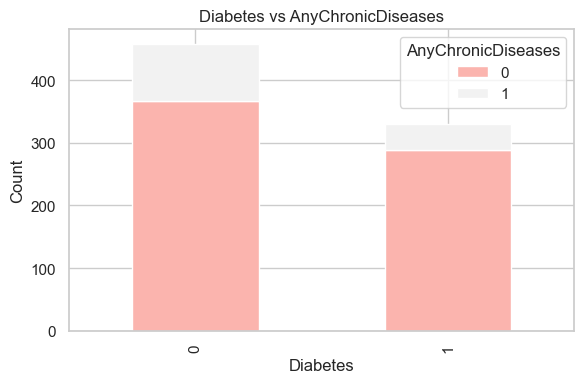


Crosstab: Diabetes vs KnownAllergies
KnownAllergies    0    1
Diabetes                
0               354  104
1               271   59


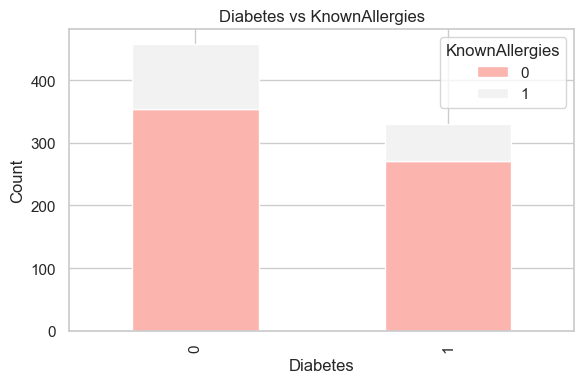


Crosstab: Diabetes vs HistoryOfCancerInFamily
HistoryOfCancerInFamily    0   1
Diabetes                        
0                        394  64
1                        300  30


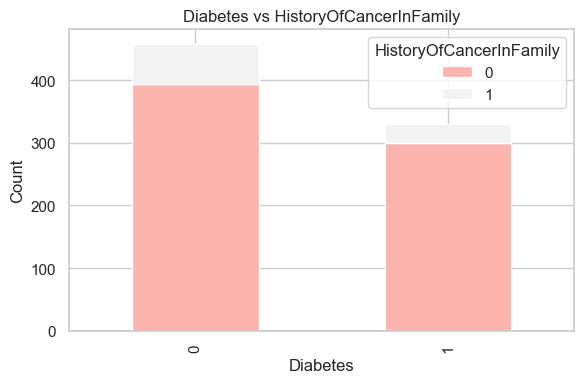


Crosstab: AnyChronicDiseases vs KnownAllergies
KnownAllergies        0    1
AnyChronicDiseases          
0                   519  136
1                   106   27


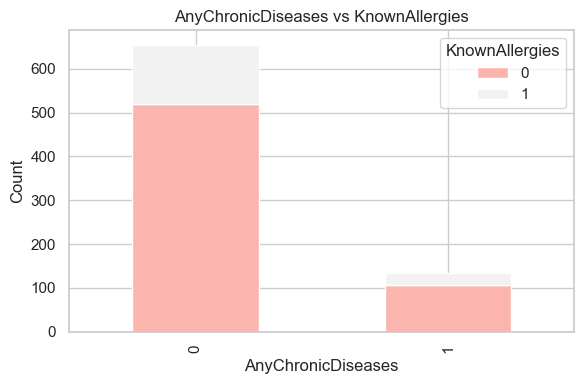


Crosstab: AnyChronicDiseases vs HistoryOfCancerInFamily
HistoryOfCancerInFamily    0   1
AnyChronicDiseases              
0                        580  75
1                        114  19


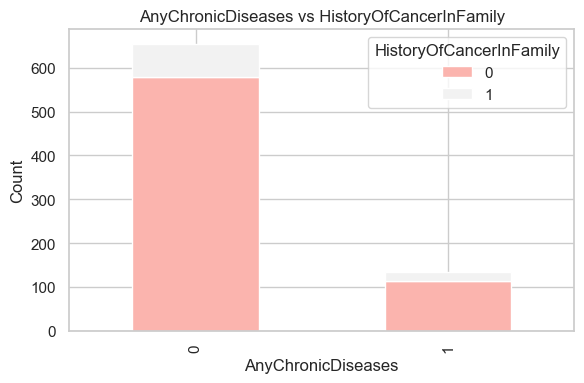


Crosstab: KnownAllergies vs HistoryOfCancerInFamily
HistoryOfCancerInFamily    0   1
KnownAllergies                  
0                        562  63
1                        132  31


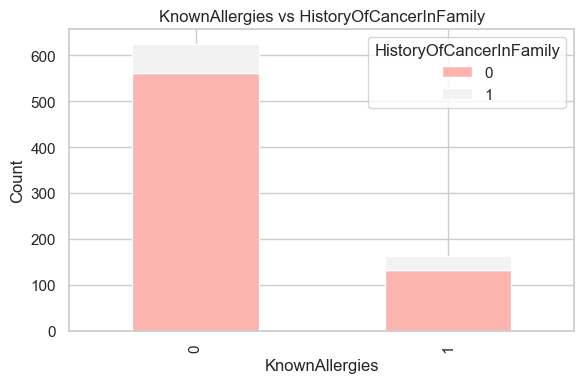

In [ ]:
for i, cat1 in enumerate(categorical_cols):
    for cat2 in categorical_cols[i+1:]:
        ct = pd.crosstab(train_data[cat1], train_data[cat2])
        print(f"\nCrosstab: {cat1} vs {cat2}")
        print(ct)
        ct.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Pastel1')
        plt.title(f"{cat1} vs {cat2}")
        plt.xlabel(cat1)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()


Error in FAMD: The 'n_components' parameter of randomized_svd must be an int in the range [1, inf). Got None instead.
Using alternative method: 9 dimensions
Variance explained: 96.13%

Calculating silhouette scores for different k values:
  k = 2: Average silhouette = 0.219
  k = 3: Average silhouette = 0.179
  k = 4: Average silhouette = 0.176
  k = 5: Average silhouette = 0.160
  k = 6: Average silhouette = 0.155
  k = 7: Average silhouette = 0.153
  k = 8: Average silhouette = 0.148
  k = 9: Average silhouette = 0.151
  k = 10: Average silhouette = 0.156

Optimal number of clusters: k = 2
Optimal average silhouette score: 0.219


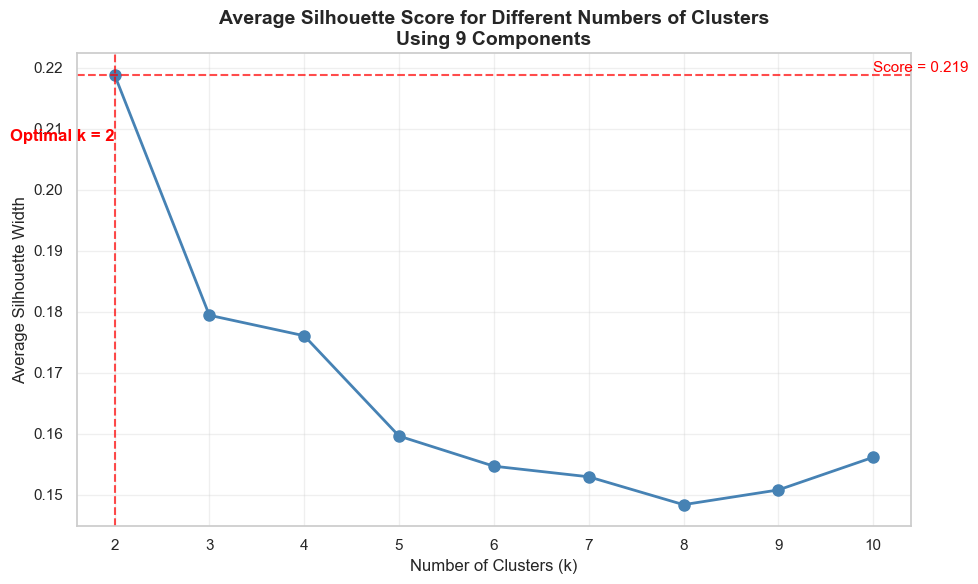


SILHOUETTE SCORE INTERPRETATION:
Average silhouette width: 0.219
✗ NO substantial clustering structure detected.

✗ CONCLUSION: There is NO strong clustering in your data (silhouette score ≤ 0.5)


In [ ]:

# -------------------------------
# Step 6: Prepare for FAMD + clustering
# -------------------------------
numerical_vars = ["Age", "Height", "Weight", "PremiumPrice"]
categorical_vars = ["Diabetes", "BloodPressureProblems", "AnyTransplants",
                    "AnyChronicDiseases", "KnownAllergies", "HistoryOfCancerInFamily",
                    "NumberOfMajorSurgeries"]

# Convert types
Medicalpremium_famd = Medicalpremium.copy()
for var in categorical_vars:
    if var in Medicalpremium_famd.columns:
        Medicalpremium_famd[var] = Medicalpremium_famd[var].astype('category')
for var in numerical_vars:
    if var in Medicalpremium_famd.columns:
        Medicalpremium_famd[var] = pd.to_numeric(Medicalpremium_famd[var], errors='coerce')

# -------------------------------
# Step 7: FAMD analysis
# -------------------------------
try:
    famd = FAMD(n_components=None, n_iter=10, random_state=42, copy=True)
    famd_fit = famd.fit(Medicalpremium_famd)
    
    eigenvalues = famd_fit.eigenvalues_
    print(f"\nEigenvalues: {eigenvalues[:5]}...")  # first 5
    dims_over_1 = sum(eigenvalues > 1)
    print(f"Number of dimensions with eigenvalue > 1: {dims_over_1}")
    
    n_dim = min(4, dims_over_1) if dims_over_1 > 0 else 2
    print(f"Using {n_dim} dimensions for clustering")
    
    coords = famd_fit.row_coordinates(Medicalpremium_famd).iloc[:, :n_dim]
    
    explained_var = famd_fit.explained_inertia_ * 100
    print(f"\nVariance explained by first {n_dim} dimensions:")
    for i in range(n_dim):
        print(f"  Dimension {i+1}: {explained_var[i]:.1f}%")
    print(f"  Total: {sum(explained_var[:n_dim]):.1f}%")
    
except Exception as e:
    print(f"Error in FAMD: {e}")
    # Alternative method: scale numeric, one-hot categorical, then PCA
    num_data = Medicalpremium[numerical_vars].copy()
    cat_data = Medicalpremium[categorical_vars].copy()
    
    scaler = StandardScaler()
    num_scaled = scaler.fit_transform(num_data)
    
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    cat_encoded = encoder.fit_transform(cat_data)
    
    combined_data = np.hstack([num_scaled, cat_encoded])
    pca = PCA(n_components=0.95)
    coords = pca.fit_transform(combined_data)
    
    n_dim = coords.shape[1]
    print(f"Using alternative method: {n_dim} dimensions")
    print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# -------------------------------
# Step 8: Silhouette analysis for KMeans
# -------------------------------
k_values = range(2, 11)
silhouette_scores = []

print("\nCalculating silhouette scores for different k values:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=25)
    cluster_labels = kmeans.fit_predict(coords)
    silhouette_avg = silhouette_score(coords, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"  k = {k}: Average silhouette = {silhouette_avg:.3f}")

optimal_k = k_values[np.argmax(silhouette_scores)]
optimal_score = max(silhouette_scores)

print(f"\nOptimal number of clusters: k = {optimal_k}")
print(f"Optimal average silhouette score: {optimal_score:.3f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, color='steelblue', linewidth=2, marker='o', markersize=8)
plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axhline(y=optimal_score, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
plt.text(optimal_k, optimal_score * 0.95, f'Optimal k = {optimal_k}', color='red', fontsize=12, fontweight='bold', ha='right')
plt.text(max(k_values), optimal_score, f'Score = {optimal_score:.3f}', color='red', fontsize=11, va='bottom')
plt.xticks(k_values)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Width')
plt.title(f'Average Silhouette Score for Different Numbers of Clusters\nUsing {n_dim} Components', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------
# Step 9: Interpretation
# -------------------------------
print("\n" + "="*60)
print("SILHOUETTE SCORE INTERPRETATION:")
print(f"Average silhouette width: {optimal_score:.3f}")

if optimal_score > 0.7:
    print("✓ STRONG clustering structure detected!")
elif optimal_score > 0.5:
    print("✓ REASONABLE clustering structure detected.")
elif optimal_score > 0.25:
    print("⚠ WEAK clustering structure detected.")
else:
    print("✗ NO substantial clustering structure detected.")

if optimal_score > 0.5:
    print("\n✓ CONCLUSION: There IS clustering in your data (silhouette score > 0.5)")
else:
    print("\n✗ CONCLUSION: There is NO strong clustering in your data (silhouette score ≤ 0.5)")
